# Unmatched CA Cases — Coverage & Time-Window Accounting

This notebook answers two questions, **for both matching methods** (fuzzy/hybrid and cluster/exact):

1. **How many CA-type C Cases were *not* matched to any RC R Case?**
2. **Of those unmatched CA cases, how many failed *only* because of the date-window filter** — i.e. an establishment-identity match (same company + state + city + NLRB region) *did* exist, but no candidate RC had its active window `[date_filed, date_closed]` covering the CA's `date_filed`?

### How we attribute the cause of non-matching

The pipeline in `match_r_to_c_cases.py` applies the date-window filter as the **last** step of both the exact and fuzzy passes (`_apply_date_filter`). So if we re-run matching with that filter **disabled**, we get every *identity candidate* pair (company/city/state/region agree) regardless of dates. Re-applying the date logic in-notebook then splits each CA case into a clean taxonomy:

| Category | Definition |
|----------|------------|
| **Matched** | ≥1 identity-candidate RC whose window covers the CA's filing date |
| **Unmatched — time-window** | ≥1 identity-candidate RC exists, but **none** has a window covering the CA date |
| **Unmatched — no identity** | Entered matching, but **no** identity-candidate RC at all |
| **Excluded — pre-filter** | Never entered matching (no address, union/long name, missing company/city/state, name-is-a-case-number) |

The first three partition the *eligible* CA universe; the fourth accounts for the gap between all CA cases and the eligible set.

> We compute *Matched* by applying the date test to the candidate set ourselves, so it is guaranteed consistent with *time-window* and *no-identity*. A cross-check against the saved output files confirms this reproduces the real pipeline output.

In [1]:
import sys, os
from pathlib import Path

import pandas as pd
import numpy as np

# Locate the project root (the folder holding the pipeline module + parquet
# files), whether this notebook is launched from the project root or from its
# own subfolder. Inputs are read from PROJECT_ROOT; outputs go to OUT_DIR
# (this notebook's own folder).
_here = Path.cwd()
PROJECT_ROOT = next((p for p in [_here, *_here.parents]
                     if (p / "match_r_to_c_cases.py").exists()), None)
assert PROJECT_ROOT is not None, \
    "Could not find match_r_to_c_cases.py in cwd or any parent directory"
OUT_DIR = _here
sys.path.insert(0, str(PROJECT_ROOT))

import match_r_to_c_cases as mr
# Point the pipeline at the parquet files in the project root (absolute paths).
mr.R_CASES_FILE = PROJECT_ROOT / "merged_R_CASES_final.parquet"
mr.R_ADDR_FILE  = PROJECT_ROOT / "merged_R_CASES_ADDRESS_with_union_flag.parquet"
mr.C_CASES_FILE = PROJECT_ROOT / "merged_C_CASES_final.parquet"
mr.C_ADDR_FILE  = PROJECT_ROOT / "merged_C_CASES_ADDRESS_with_union_flag.parquet"

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print("project root:", PROJECT_ROOT)
print("output dir:  ", OUT_DIR)
print("pandas", pd.__version__)

pandas 2.1.4


## Step 1 — Eligible CA universe per method

`load_and_prepare()` performs exactly the filtering the real run does: keep `type == "CA"`, join the address table, drop union/long-name/missing/case-number rows. Anything dropped here is the **Excluded — pre-filter** bucket.

The two methods differ only in which company column they match on:
- **Fuzzy** uses the raw `company_name` (preprocessed in-pipeline) → run in `hybrid` mode.
- **Cluster** uses `cluster_representative` (preprocessed upstream) → run in `exact` mode.

The eligible CA *set* can differ slightly between methods, because a CA row whose `cluster_representative` is empty would be dropped on the cluster side but kept on the fuzzy side (and vice-versa). We therefore compute the universe separately for each.

In [2]:
# Full CA universe, before any address join / filtering — the outer denominator.
_c_cases = pd.read_parquet(mr.C_CASES_FILE)
if "case_number" in _c_cases.columns and "c_case_number" not in _c_cases.columns:
    _c_cases = _c_cases.rename(columns={"case_number": "c_case_number"})
n_ca_all = _c_cases.loc[_c_cases["type"] == "CA", "c_case_number"].nunique()
print(f"All CA-type C Cases (raw, distinct case numbers): {n_ca_all:,}")

All CA-type C Cases (raw, distinct case numbers): 771,459


In [3]:
# Prepare eligible rc/ac frames for each method.
print("="*70, "\nFUZZY method — company_name\n", "="*70, sep="")
rc_fz, ac_fz = mr.load_and_prepare(company_column="company_name")

print("\n", "="*70, "\nCLUSTER method — cluster_representative\n", "="*70, sep="")
rc_cl, ac_cl = mr.load_and_prepare(company_column="cluster_representative")

n_ca_elig_fz = ac_fz["c_case_number"].nunique()
n_ca_elig_cl = ac_cl["c_case_number"].nunique()
print(f"\nEligible CA cases — fuzzy:   {n_ca_elig_fz:,}")
print(f"Eligible CA cases — cluster: {n_ca_elig_cl:,}")

FUZZY method — company_name
Loading parquet files …
  R_CASES rows:            197,253
  R_CASES_ADDRESS rows:    197,451
  C_CASES rows:          1,038,762
  C_CASES_ADDRESS rows:  1,038,762
  ℹ Renamed 'case_number' → 'r_case_number' in R-side table
  ℹ Renamed 'case_number' → 'r_case_number' in R-side table
  ℹ Renamed 'case_number' → 'c_case_number' in C-side table
  ℹ Renamed 'case_number' → 'c_case_number' in C-side table

  RC-type R Cases:         144,319
  CA-type C Cases:         771,459
  ⚠ Dropping 3,037 R_CASES_ADDRESS rows flagged as union name or too long
  ⚠ Dropping 185,447 C_CASES_ADDRESS rows flagged as union name or too long
  filter_case_numbers: removed 2 rows matching NLRB case-number pattern from 'company_name'

Preprocessing company names (source column: company_name) …
  ⚠ Dropping 468 RC rows with missing company/state/city
  ⚠ Dropping 2,686 AC rows with missing company/state/city

CLUSTER method — cluster_representative
Loading parquet files …
  R_CASES row

## Step 2 — Identity candidates (date filter disabled)

We monkeypatch `mr._apply_date_filter` to a pass-through so the exact/fuzzy passes return **all** identity-candidate pairs. The candidate rows still carry `r_date_filed`, `r_date_closed`, and `c_date_filed`, so we can re-apply the date test ourselves afterwards.

The fuzzy/hybrid pass is the expensive step (a few minutes); the cluster/exact pass is fast.

In [4]:
from contextlib import contextmanager

@contextmanager
def date_filter_disabled():
    original = mr._apply_date_filter
    mr._apply_date_filter = lambda merged: merged  # identity: keep all candidates
    try:
        yield
    finally:
        mr._apply_date_filter = original

def identity_candidates(rc, ac, match_mode):
    """All identity-candidate (RC, CA) pairs, ignoring the date window."""
    with date_filter_disabled():
        return mr.match_cases(rc, ac, match_mode=match_mode)

In [5]:
# Fuzzy = hybrid (exact + fuzzy). This is the slow cell.
cand_fz = identity_candidates(rc_fz, ac_fz, match_mode="hybrid")
print(f"\nFuzzy identity-candidate pairs (no date filter): {len(cand_fz):,}")

  RC cases dropped (still open / no close date): 702
  ⚠ Dropping 5 RC cases where date_closed < date_filed

── Exact matching on (company, state) + fuzzy city (threshold=85) ──


Exact RC → AC: 100%|██████████| 29/29 [00:12<00:00,  2.25chunk/s]


  Candidate pairs after location join: 595,592
  Matches after date-window filter:    339,796

  Running fuzzy pass on all 141,025 RC cases (not just unmatched) …

── Fuzzy matching (company threshold=82, city threshold=85) ──
  Blocking on normalised state + region …
  (state, region) blocks with both RC and AC cases: 610


Fuzzy by state+region: 100%|██████████| 610/610 [08:19<00:00,  1.22block/s]


  Candidate pairs after state block + fuzzy name + city gate: 842,334
  Matches after date-window filter: 454,411
  Fuzzy pairs already found by exact pass (removed): 339,796
  New fuzzy pairs (additive):                        114,615

  Combined matches (exact + fuzzy): 454,411

Fuzzy identity-candidate pairs (no date filter): 454,411


In [6]:
# Cluster = exact on cluster_representative.
cand_cl = identity_candidates(rc_cl, ac_cl, match_mode="exact")
print(f"\nCluster identity-candidate pairs (no date filter): {len(cand_cl):,}")

  RC cases dropped (still open / no close date): 702
  ⚠ Dropping 5 RC cases where date_closed < date_filed

── Exact matching on (company, state) + fuzzy city (threshold=85) ──


Exact RC → AC: 100%|██████████| 29/29 [00:14<00:00,  2.04chunk/s]


  Candidate pairs after location join: 1,208,649
  Matches after date-window filter:    666,102

Cluster identity-candidate pairs (no date filter): 666,102


## Step 3 — Classify every CA case

For each candidate pair, `date_ok` is the exact test the pipeline uses:
`r_date_filed <= c_date_filed <= r_date_closed`.

- A CA case is **Matched** if *any* of its candidate pairs has `date_ok`.
- It is **time-window** if it has candidates but *none* are `date_ok`.
- A CA case in the eligible set with no candidate row at all is **no-identity**.

In [7]:
def classify(candidates, eligible_ca_ids, n_ca_all):
    """Return (summary dict, detail frame) decomposing CA cases by match outcome."""
    cand = candidates.copy()
    # Date test — identical to mr._apply_date_filter, applied at pair level.
    cand["date_ok"] = (
        (cand["c_date_filed"] >= cand["r_date_filed"])
        & (cand["c_date_filed"] <= cand["r_date_closed"])
    )

    # CA-level rollup of candidate outcomes.
    per_ca = cand.groupby("c_case_number").agg(
        n_candidate_rc=("r_case_number", "nunique"),
        any_date_ok=("date_ok", "any"),
        c_date_filed=("c_date_filed", "first"),
    )

    matched_ca   = set(per_ca.index[per_ca["any_date_ok"]])
    candidate_ca = set(per_ca.index)
    tw_ca        = candidate_ca - matched_ca               # had identity, no date hit
    eligible_ca  = set(eligible_ca_ids)
    noid_ca      = eligible_ca - candidate_ca              # eligible, no identity candidate
    excluded     = n_ca_all - len(eligible_ca)             # never entered matching

    # Sub-split of time-window failures: did the CA fall before/after the window?
    tw_pairs = cand[cand["c_case_number"].isin(tw_ca)].copy()
    tw_pairs["before_window"] = tw_pairs["c_date_filed"] < tw_pairs["r_date_filed"]
    tw_pairs["after_window"]  = tw_pairs["c_date_filed"] > tw_pairs["r_date_closed"]
    tw_roll = tw_pairs.groupby("c_case_number").agg(
        any_before=("before_window", "any"),
        any_after=("after_window", "any"),
        c_date_filed=("c_date_filed", "first"),
    )
    tw_missing_date = int(tw_roll["c_date_filed"].isna().sum())
    tw_only_before  = int(((tw_roll["any_before"]) & (~tw_roll["any_after"])).sum())
    tw_only_after   = int(((~tw_roll["any_before"]) & (tw_roll["any_after"])).sum())
    tw_both         = int(((tw_roll["any_before"]) & (tw_roll["any_after"])).sum())

    summary = {
        "all_ca": n_ca_all,
        "eligible_ca": len(eligible_ca),
        "excluded_prefilter": excluded,
        "matched": len(matched_ca),
        "unmatched_total": len(eligible_ca) - len(matched_ca),
        "unmatched_time_window": len(tw_ca),
        "unmatched_no_identity": len(noid_ca),
        # before_window: CA filed BEFORE the petition (c_date_filed < r_date_filed)
        # after_window:  CA filed AFTER the case closed (c_date_filed > r_date_closed)
        "tw_only_before_window": tw_only_before,
        "tw_only_after_window": tw_only_after,
        "tw_both_directions": tw_both,
        "tw_missing_c_date": tw_missing_date,
    }
    detail = {
        "matched_ca": matched_ca,
        "time_window_ca": tw_ca,
        "no_identity_ca": noid_ca,
        "cand_with_date_ok": cand,
        "tw_roll": tw_roll,
    }
    return summary, detail

In [8]:
sum_fz, det_fz = classify(cand_fz, ac_fz["c_case_number"], n_ca_all)
sum_cl, det_cl = classify(cand_cl, ac_cl["c_case_number"], n_ca_all)

core = ["all_ca", "eligible_ca", "excluded_prefilter", "matched",
        "unmatched_total", "unmatched_time_window", "unmatched_no_identity"]
report = pd.DataFrame({"fuzzy": {k: sum_fz[k] for k in core},
                       "cluster": {k: sum_cl[k] for k in core}})
report

,fuzzy,cluster
all_ca,771459,771459
eligible_ca,754030,754030
excluded_prefilter,17429,17429
matched,45824,54697
unmatched_total,708206,699333
unmatched_time_window,146964,181546
unmatched_no_identity,561242,517787


### Read the numbers as shares

Two denominators matter:
- **% of eligible** — among CA cases that actually entered matching.
- **% of all CA** — among every CA case in the data (includes the pre-filter excluded bucket).

In [9]:
def shares(summary):
    elig = summary["eligible_ca"]; allc = summary["all_ca"]
    rows = {}
    for k in ["matched", "unmatched_total", "unmatched_time_window", "unmatched_no_identity"]:
        rows[k] = {"n": summary[k],
                   "% of eligible": 100*summary[k]/elig,
                   "% of all CA": 100*summary[k]/allc}
    rows["excluded_prefilter"] = {"n": summary["excluded_prefilter"],
                                  "% of eligible": np.nan,
                                  "% of all CA": 100*summary["excluded_prefilter"]/allc}
    return pd.DataFrame(rows).T

print("="*30, "FUZZY", "="*30)
display(shares(sum_fz).round(2))
print("="*30, "CLUSTER", "="*30)
display(shares(sum_cl).round(2))

============================== FUZZY ==============================


,n,% of eligible,% of all CA
matched,45824.0,6.08,5.94
unmatched_total,708206.0,93.92,91.80
unmatched_time_window,146964.0,19.49,19.05
unmatched_no_identity,561242.0,74.43,72.75
excluded_prefilter,17429.0,NaN,2.26


============================== CLUSTER ==============================


,n,% of eligible,% of all CA
matched,54697.0,7.25,7.09
unmatched_total,699333.0,92.75,90.65
unmatched_time_window,181546.0,24.08,23.53
unmatched_no_identity,517787.0,68.67,67.12
excluded_prefilter,17429.0,NaN,2.26


### Time-window failures — direction of the miss

For CA cases that failed *only* on the date window, was the charge filed **before** any candidate petition was filed, **after** every candidate case had closed, or a mix across different candidate RCs? (`missing_c_date` = the CA had no usable `date_filed`, so the window test could never pass.)

In [10]:
tw_cols = ["unmatched_time_window", "tw_only_before_window",
           "tw_only_after_window", "tw_both_directions", "tw_missing_c_date"]
tw_report = pd.DataFrame({"fuzzy": {k: sum_fz[k] for k in tw_cols},
                          "cluster": {k: sum_cl[k] for k in tw_cols}})
tw_report.index = ["time-window failures (total)",
                   "  only before petition window (CA earlier than r_date_filed)",
                   "  only after case closed (CA later than r_date_closed)",
                   "  both directions (different candidate RCs)",
                   "  CA had no usable date_filed"]
tw_report

,fuzzy,cluster
time-window failures (total),146964,181546
only before petition window (CA earlier than r_date_filed),35422,41012
only after case closed (CA later than r_date_closed),87111,104502
both directions (different candidate RCs),24431,36032
CA had no usable date_filed,0,0


## Cross-check against the saved pipeline outputs

The *Matched* set we derived should match the distinct CA cases in the committed output files (`rc_ac_matches.parquet`, `rc_ac_cluster_matches_20260517.parquet`). Small differences are acceptable only if the outputs were generated from a different data snapshot; ideally they are zero.

In [11]:
def disk_matched_ca(name):
    p = PROJECT_ROOT / name
    if not p.exists():
        return None
    return set(pd.read_parquet(p)["c_case_number"].unique())

for label, derived, path in [
    ("fuzzy",   det_fz["matched_ca"], "rc_ac_matches.parquet"),
    ("cluster", det_cl["matched_ca"], "rc_ac_cluster_matches_20260517.parquet"),
]:
    disk = disk_matched_ca(path)
    if disk is None:
        print(f"{label}: {path} not found — skipping cross-check"); continue
    print(f"{label}: derived matched CA={len(derived):,}  disk={len(disk):,}  "
          f"derived-only={len(derived-disk):,}  disk-only={len(disk-derived):,}")

fuzzy: derived matched CA=45,824  disk=45,824  derived-only=0  disk-only=0
cluster: derived matched CA=54,697  disk=54,697  derived-only=0  disk-only=0


## Step 4 — Inspect the time-window failures

A sample of CA cases that *would* have matched on establishment identity but were excluded purely by the date window, shown with their nearest candidate RC window.

In [12]:
def time_window_examples(detail, n=15, seed=0):
    cand = detail["cand_with_date_ok"]
    tw = cand[cand["c_case_number"].isin(detail["time_window_ca"])].copy()
    # Nearest miss: smallest absolute gap to the window edge.
    gap_before = (tw["r_date_filed"] - tw["c_date_filed"]).dt.days        # >0 if CA before window
    gap_after  = (tw["c_date_filed"] - tw["r_date_closed"]).dt.days       # >0 if CA after window
    tw["days_outside_window"] = np.where(gap_before > 0, gap_before, gap_after)
    tw = tw.sort_values("days_outside_window")
    nearest = tw.drop_duplicates("c_case_number", keep="first")
    cols = ["c_case_number", "r_case_number", "c_company_name", "r_company_name",
            "c_city", "r_city", "c_date_filed", "r_date_filed", "r_date_closed",
            "days_outside_window", "match_method"]
    cols = [c for c in cols if c in nearest.columns]
    return nearest[cols].sample(min(n, len(nearest)), random_state=seed)

print("FUZZY — nearest-miss time-window examples")
display(time_window_examples(det_fz))
print("CLUSTER — nearest-miss time-window examples")
display(time_window_examples(det_cl))

FUZZY — nearest-miss time-window examples


,c_case_number,r_case_number,c_company_name,r_company_name,c_city,r_city,c_date_filed,r_date_filed,r_date_closed,days_outside_window,match_method
85081,05-CA-021946,05-RC-013508,"RICHFOOD, INC.","RICHFOOD, INC.",MECHANICSVILLE,MECHANICSVILLE,1991-05-06,1990-09-12,1990-12-25,132,exact
10178,01-CA-042706,01-RC-021408,Calais Regional Hospital,Calais Regional Hospital,Calais,Calais,2005-07-25,2001-08-20,2001-10-15,1379,exact
274433,19-CA-106106,19-RC-015374,JH Kelly,"J H Kelly, LLC",LONGVIEW,Longview,2013-05-29,2011-01-13,2011-03-17,804,fuzzy
146739,07-CA-037578,07-RC-021244,ST. JOHN HOSPITAL,ST. JOHN HOSPITAL,DETROIT,DETROIT,1995-08-17,1998-02-03,1998-03-13,901,exact
47171,03-CA-013334,03-RC-009040,OCCIDENTAL CHEMICAL CORPORATION,OCCIDENTAL CHEMICAL CORPORATION,NIAGARA FALLS,NIAGARA FALLS,1986-07-14,1987-03-11,1987-03-25,240,exact
374400,28-CA-011385,28-RC-004687,BELL TRANS,BELL TRANS,LAS VEGAS,LAS VEGAS,1992-03-09,1989-04-10,1989-11-29,831,exact
74985,04-CA-033525,04-RC-020846,Raymour & Flanigan,Raymour & Flanigan,Philadelphia,Philadelphia,2004-11-23,2004-05-28,2004-08-03,112,exact
88755,05-CA-033252,05-RC-014379,United States Post Office,UNITED STATES POSTAL SERVICE,Washington,WASHINGTON,2006-09-25,1996-07-23,1996-09-18,3659,exact
236561,15-CA-014339,15-RC-007121,BAYOU STEEL CORPORATION,BAYOU STEEL CORPORATION,LAPLACE,LAPLACE,1997-05-20,1984-10-01,1987-03-30,3704,exact
178167,09-CA-026776,09-RC-016264,HOPPLE PLASTICS,"HOPPLE PLASTICS, INC.",FLORENCE,FLORENCE,1989-08-29,1993-07-21,1993-09-14,1422,exact


CLUSTER — nearest-miss time-window examples


,c_case_number,r_case_number,c_company_name,r_company_name,c_city,r_city,c_date_filed,r_date_filed,r_date_closed,days_outside_window,match_method
329315,13-CA-040287,13-RC-020637,"Culinary Foods, Inc.","Culinary Foods, Inc.",Chicago,Chicago,2002-06-24,2001-07-27,2001-10-31,236,exact
584754,29-CA-017767,29-RC-009378,CENTRAL MANOR HOME ALSO 1115 NURSING HOME,Central Manor Home for Adults,FAR ROCKAWAY,Far Rockaway,1993-10-22,1999-11-03,1999-12-20,2203,exact
252893,08-CA-039259,08-RC-014825,Oberlin College,OBERLIN COLLEGE,Oberlin,OBERLIN,2010-12-14,1992-12-23,1993-03-19,6479,exact
436051,21-CA-031471,21-RC-017666,"BRIDGESTONE/FIRESTONE, INC.",FIRESTONE TIRE & RUBBER CO.,SAN DIEGO,SAN DIEGO,1996-07-31,1985-08-13,1985-09-30,3957,exact
473674,22-CA-028010,22-RC-012796,"First Student, Inc.",First Student,Piscataway,Piscataway,2007-07-06,2007-04-17,2007-06-06,30,exact
393490,19-CA-024180,19-RC-013059,BELLINGHAM-WHATCOM COUNTY HUMANE SOCIETY,BELLINGHAM-WHATCOM COUNTY HUMANE SOCIETY & SPCA,BELLINGHAM,BELLINGHAM,1995-10-13,1995-07-05,1995-08-24,50,exact
400095,19-CA-029556,19-RC-014553,Sparrows Electric,Sparrows Electric,Anchorage,Anchorage,2004-12-08,2004-07-21,2004-07-23,138,exact
8109,01-CA-031287,01-RC-020256,NEW ENGLAND POWER SERVICE CO.,NEW ENGLAND POWER SERVICE,WESTBORO,WESTBORO,1994-01-18,1995-02-15,1995-04-12,393,exact
67704,03-CA-013425,03-RC-008862,COLONIAL FORD,COLONIAL FORD,TONAWANDA,TONAWANDA,1986-09-08,1986-02-18,1986-07-30,40,exact
524804,27-CA-017963,27-RC-008040,Stillwater Mining Co.,Stillwater Mining Company,Nye,Nye,2002-04-12,2000-04-28,2000-06-19,662,exact


In [13]:
# How close were the misses? Distribution of days outside the window (nearest candidate).
def days_outside_distribution(detail):
    cand = detail["cand_with_date_ok"]
    tw = cand[cand["c_case_number"].isin(detail["time_window_ca"])].copy()
    gb = (tw["r_date_filed"] - tw["c_date_filed"]).dt.days
    ga = (tw["c_date_filed"] - tw["r_date_closed"]).dt.days
    tw["days_outside_window"] = np.where(gb > 0, gb, ga)
    nearest = (tw.sort_values("days_outside_window")
                 .drop_duplicates("c_case_number", keep="first"))
    return nearest["days_outside_window"].describe(
        percentiles=[.1, .25, .5, .75, .9])

print("FUZZY days outside window (nearest candidate):")
display(days_outside_distribution(det_fz).round(1))
print("CLUSTER days outside window (nearest candidate):")
display(days_outside_distribution(det_cl).round(1))

FUZZY days outside window (nearest candidate):


count    146964.0
mean       1507.9
std        2135.8
min           1.0
10%          42.0
25%         162.0
50%         602.0
75%        1946.0
90%        4298.0
max       15373.0
Name: days_outside_window, dtype: float64

CLUSTER days outside window (nearest candidate):


count    181546.0
mean       1523.1
std        2149.4
min           1.0
10%          44.0
25%         167.0
50%         615.0
75%        1961.0
90%        4358.0
max       15568.0
Name: days_outside_window, dtype: float64

## Step 5 — Save the unmatched breakdowns

Write per-method CSVs so the unmatched CA cases (and especially the time-window failures) can be reviewed downstream.

In [14]:
def save_unmatched(detail, summary, method):
    # Combined summary row.
    pd.DataFrame([summary]).to_csv(OUT_DIR / f"unmatched_ca_{method}_summary.csv", index=False)

    # Time-window failures with nearest candidate context.
    cand = detail["cand_with_date_ok"]
    tw = cand[cand["c_case_number"].isin(detail["time_window_ca"])].copy()
    gb = (tw["r_date_filed"] - tw["c_date_filed"]).dt.days
    ga = (tw["c_date_filed"] - tw["r_date_closed"]).dt.days
    tw["days_outside_window"] = np.where(gb > 0, gb, ga)
    nearest = (tw.sort_values("days_outside_window")
                 .drop_duplicates("c_case_number", keep="first"))
    keep = ["c_case_number", "r_case_number", "c_company_name", "r_company_name",
            "c_city", "r_city", "c_state", "c_date_filed",
            "r_date_filed", "r_date_closed", "days_outside_window", "match_method"]
    keep = [c for c in keep if c in nearest.columns]
    nearest[keep].to_csv(OUT_DIR / f"unmatched_ca_{method}_time_window.csv", index=False)

    # Bare list of no-identity unmatched CA case numbers.
    pd.Series(sorted(detail["no_identity_ca"]), name="c_case_number").to_csv(
        OUT_DIR / f"unmatched_ca_{method}_no_identity.csv", index=False)
    print(f"{method}: wrote summary, {len(nearest):,} time-window rows, "
          f"{len(detail['no_identity_ca']):,} no-identity ids")

save_unmatched(det_fz, sum_fz, "fuzzy")
save_unmatched(det_cl, sum_cl, "cluster")

fuzzy: wrote summary, 146,964 time-window rows, 561,242 no-identity ids
cluster: wrote summary, 181,546 time-window rows, 517,787 no-identity ids


## Step 6 — Visual summary

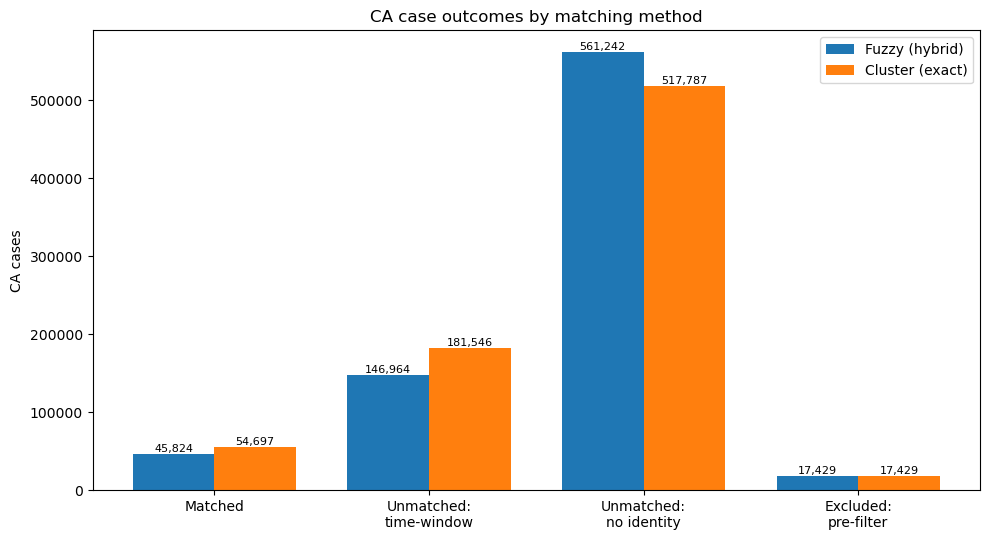

In [15]:
import matplotlib.pyplot as plt

cats = ["matched", "unmatched_time_window", "unmatched_no_identity", "excluded_prefilter"]
labels = ["Matched", "Unmatched:\ntime-window", "Unmatched:\nno identity",
          "Excluded:\npre-filter"]
fz_vals = [sum_fz[c] for c in cats]
cl_vals = [sum_cl[c] for c in cats]

x = np.arange(len(cats)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
b1 = ax.bar(x - w/2, fz_vals, w, label="Fuzzy (hybrid)")
b2 = ax.bar(x + w/2, cl_vals, w, label="Cluster (exact)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("CA cases"); ax.set_title("CA case outcomes by matching method")
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{int(bar.get_height()):,}",
                    (bar.get_x()+bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

## Step 7 — Substance or failure? Allegation profile of matched vs unmatched

If the low CA match rate is *substantive* (most CA charges genuinely have no contemporaneous RC drive), the **allegation mix** should differ sharply between matched and unmatched charges:

- **§8(a)(5)** = *refusal to bargain* — only possible where a union **already** represents the unit, so there is usually **no concurrent RC petition**. Should dominate the **unmatched** set.
- **§8(a)(1)** (coercion) and **§8(a)(3)** (discrimination, e.g. firing organizers) are the classic *during-an-organizing-campaign* violations. Should concentrate among the **matched** set.

Values below are the share of CA cases carrying each subsection (a charge can list several). "Matched" = in the method's matched set; "Unmatched" = every other CA case.

In [16]:
# Allegation flags over the full CA universe.
_c = pd.read_parquet(mr.C_CASES_FILE)
if "case_number" in _c.columns and "c_case_number" not in _c.columns:
    _c = _c.rename(columns={"case_number": "c_case_number"})
_ca = _c[_c["type"] == "CA"][["c_case_number", "allegations"]].copy()
_a = _ca["allegations"].fillna("").astype(str)
_ca["s8a1_coercion"]       = _a.str.contains(r"8\(a\)\(1\)")
_ca["s8a3_discrimination"] = _a.str.contains(r"8\(a\)\(3\)")
_ca["s8a5_refuse_bargain"] = _a.str.contains(r"8\(a\)\(5\)")
_ca["s8a5_only_not_3"]     = _ca["s8a5_refuse_bargain"] & ~_ca["s8a3_discrimination"]

def allegation_profile(matched_ca):
    _ca["matched"] = _ca["c_case_number"].isin(matched_ca)
    g = (_ca.groupby("matched")[["s8a1_coercion", "s8a3_discrimination",
                                 "s8a5_refuse_bargain", "s8a5_only_not_3"]]
            .mean().round(3))
    g.index = ["UNMATCHED", "MATCHED"]
    return g

print("FUZZY — allegation profile (share of CA carrying each subsection)")
display(allegation_profile(det_fz["matched_ca"]))
print("CLUSTER — allegation profile")
display(allegation_profile(det_cl["matched_ca"]))

FUZZY — allegation profile (share of CA carrying each subsection)


,s8a1_coercion,s8a3_discrimination,s8a5_refuse_bargain,s8a5_only_not_3
UNMATCHED,0.702,0.214,0.280,0.232
MATCHED,0.849,0.273,0.076,0.046


CLUSTER — allegation profile


,s8a1_coercion,s8a3_discrimination,s8a5_refuse_bargain,s8a5_only_not_3
UNMATCHED,0.700,0.213,0.282,0.234
MATCHED,0.843,0.273,0.083,0.051


## Step 8 — Recall bounds: how much *could* matching be failing?

The allegation check tells us the low rate is *plausible*; this step bounds the **false negatives** directly.

**Relax-the-gates ladder.** Re-do identity matching on exact preprocessed names, progressively dropping the location keys (region → city → state). At each rung we count CA cases that gain *any* identity candidate, and how many of those are **currently in the no-identity bucket** — i.e. the recall we could recover by loosening that gate. (Exact name + exact city here, so the strict rung is a touch lower than the pipeline's fuzzy-city candidates; it's the *increments between rungs* that matter.)

The last rung, **name only**, is the ceiling: a no-identity CA whose company name never appears in *any* RC genuinely had no organizing petition at that firm — it cannot be a matching failure.

In [17]:
SEP = "\x1f"
def _mkkey(df, cols):
    s = df[cols[0]].astype(str)
    for c in cols[1:]:
        s = s + SEP + df[c].astype(str)
    return s

def relax_ladder(rc, ac, no_identity_ca, label):
    rungs = [
        ("name+state+region+city (strict)", ["match_company", "match_state", "match_region", "match_city"]),
        ("drop city   -> name+state+region", ["match_company", "match_state", "match_region"]),
        ("drop region -> name+state+city",   ["match_company", "match_state", "match_city"]),
        ("name+state",                       ["match_company", "match_state"]),
        ("name only (ceiling)",              ["match_company"]),
    ]
    noid = set(no_identity_ca)
    rows = []
    for name, cols in rungs:
        rk = set(_mkkey(rc, cols).unique())
        hit = _mkkey(ac, cols).isin(rk)
        ca_ids = set(ac.loc[hit, "c_case_number"])
        rows.append({"rung": name,
                     "CA_with_identity_candidate": len(ca_ids),
                     "of_which_currently_no_identity": len(ca_ids & noid)})
    print(f"-- {label}: relax-the-gates ladder (exact preprocessed name) --")
    return pd.DataFrame(rows).set_index("rung")

display(relax_ladder(rc_fz, ac_fz, det_fz["no_identity_ca"], "FUZZY names"))
display(relax_ladder(rc_cl, ac_cl, det_cl["no_identity_ca"], "CLUSTER names"))

-- FUZZY names: relax-the-gates ladder (exact preprocessed name) --


,CA_with_identity_candidate,of_which_currently_no_identity
rung,,
name+state+region+city (strict),148085,687
drop city -> name+state+region,191857,39406
drop region -> name+state+city,154269,6398
name+state,211340,57932
name only (ceiling),347940,191020


-- CLUSTER names: relax-the-gates ladder (exact preprocessed name) --


,CA_with_identity_candidate,of_which_currently_no_identity
rung,,
name+state+region+city (strict),232393,1013
drop city -> name+state+region,303031,66788
drop region -> name+state+city,242062,10586
name+state,330514,94271
name only (ceiling),493085,256842


In [18]:
# Most suspicious misses: §8(a)(3)-only (discrimination, implies an active campaign)
# that are currently no-identity. If the company name appears anywhere in RC, that
# is a likely *true* false negative worth manual review.
def suspicious_misses(rc, ac, no_identity_ca, label):
    noid = set(no_identity_ca)
    s3only = set(_ca.loc[_ca["s8a3_discrimination"] & ~_ca["s8a5_refuse_bargain"],
                         "c_case_number"])
    target = noid & s3only
    rc_names = set(rc["match_company"].unique())
    ac_t = ac[ac["c_case_number"].isin(target)]
    name_hit = set(ac_t.loc[ac_t["match_company"].isin(rc_names), "c_case_number"])
    pct = 100 * len(name_hit) / max(len(target), 1)
    print(f"{label}:")
    print(f"  no-identity unmatched CA:                 {len(noid):,}")
    print(f"  ... §8(a)(3)-only (suspicious campaign):  {len(target):,}")
    print(f"  ... whose company name DOES appear in RC: {len(name_hit):,}  "
          f"({pct:.1f}% of suspicious -> candidate true misses)")
    return name_hit

_fz_susp = suspicious_misses(rc_fz, ac_fz, det_fz["no_identity_ca"], "FUZZY")
_cl_susp = suspicious_misses(rc_cl, ac_cl, det_cl["no_identity_ca"], "CLUSTER")

# Save the suspicious candidate-true-miss case numbers for manual review.
pd.Series(sorted(_fz_susp), name="c_case_number").to_csv(
    OUT_DIR / "suspected_false_negative_ca_fuzzy.csv", index=False)
pd.Series(sorted(_cl_susp), name="c_case_number").to_csv(
    OUT_DIR / "suspected_false_negative_ca_cluster.csv", index=False)
print("\nSaved suspected_false_negative_ca_{fuzzy,cluster}.csv")

FUZZY:
  no-identity unmatched CA:                 561,242
  ... §8(a)(3)-only (suspicious campaign):  90,646
  ... whose company name DOES appear in RC: 33,319  (36.8% of suspicious -> candidate true misses)
CLUSTER:
  no-identity unmatched CA:                 517,787
  ... §8(a)(3)-only (suspicious campaign):  82,135
  ... whose company name DOES appear in RC: 43,715  (53.2% of suspicious -> candidate true misses)

Saved suspected_false_negative_ca_{fuzzy,cluster}.csv


### Interpreting the recall bounds

- **Region/city increments** show how much the strict equi-keys cost. A large jump when dropping **region** flags establishments that filed RC and CA in different Regional Offices (boundary changes, HQ-vs-site) — a fixable matching limitation, not a substantive absence.
- **Name-only ceiling** (`of_which_currently_no_identity` at the last rung) is the maximum recall recoverable by loosening location/time entirely. The rest of the no-identity bucket — names that appear in *no* RC — is substantively unmatchable: those firms simply never had an organizing petition in the data.
- **§8(a)(3)-only suspects whose name appears in RC** are the highest-value manual-audit pool (saved to CSV): discrimination charges that should accompany a campaign, at a firm that *did* petition somewhere. A low count here is reassuring; a high count points to real false negatives.

## Takeaways

- **Unmatched CA total** = eligible CA − matched. The large majority of CA charges have no RC counterpart at all, which is expected: most unfair-labor-practice charges are not tied to a contemporaneous union-certification petition at the same establishment.
- **Time-window share** is the interesting diagnostic: these are CA cases where the *establishment* was found among RC petitions, but the charge fell outside every candidate petition's active window. The `days_outside_window` distribution shows whether widening the window (or relaxing it to "same establishment, any time") would recover many of them.
- Compare the **two methods**: clustering generally surfaces more identity candidates (broader entity resolution), so it typically converts some *no-identity* cases into either *matched* or *time-window* cases relative to fuzzy.
- Next step (per the project plan): bring **ZIP code** into the identity test to sharpen establishment matching, and revisit whether the date window should be a hard gate or a soft/scored feature.